##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** [Enter Group Number]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]

---

## 0. Iteration setup

**Import libraries**

In [1]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)
import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

**Load & Merge dataset(s)**

In [2]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID

df_ships2 = pd.read_csv("ships_merged.csv")
df_ships2.head(5)

,Unnamed: 0.1,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,0,0,7316160254,4950.0,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,1,1,7316115206,18999.0,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,2,2,7315865657,4000.0,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,3,3,7314772431,6495.0,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,4,4,7311539325,3995.0,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle


In [3]:
df_ships3 = pd.read_csv("ship_performance_logs_iter3.csv")
df_ships3.head(5)

,Ship_ID,Lightyears_Traveled,Registration_Status
0,7316814884,40.610676,Refurbished
1,7316814758,66.153551,Imperial Certified
2,7316814989,10.844388,Refurbished
3,7316743432,29.576094,Refurbished
4,7316356412,122.111671,Refurbished


In [4]:
#left join to keep previous data intact without introducing more unknown data
df_merged2 = df_ships2.merge(df_ships3, left_on='Ship_ID', right_on='Ship_ID', how='left')
df_merged2.head()

,Unnamed: 0.1,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Lightyears_Traveled,Registration_Status
0,0,0,7316160254,4950.0,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle,104.554402,Smuggler Logic
1,1,1,7316115206,18999.0,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle,21.540154,Imperial Certified
2,2,2,7315865657,4000.0,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle,87.313033,Imperial Certified
3,3,3,7314772431,6495.0,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle,144.885019,Imperial Certified
4,4,4,7311539325,3995.0,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle,124.394203,Smuggler Logic


---

## 1. Business Understanding

**Situation description**

*Describe the final problem. Why is Nebula Brokerage moving from the simple models (iterations 1 and 2) to a machine learning approach?*

**Business objective(s)**

*Justify why an AI-driven pipeline (predicting both Galactic Credits and Condition) adds business value.*

**Data mining goal(s)**

*Explain the two modeling tasks for this iteration.*

**Success criteria**

*Determine the success criteria.*

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [ ]:
df_merged2.info()
df_merged2.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368314 entries, 0 to 368313
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0.1         368314 non-null  int64  
 1   Unnamed: 0           368314 non-null  int64  
 2   Ship_ID              368314 non-null  int64  
 3   Galactic_Credits     368314 non-null  float64
 4   Model_Cycle          368314 non-null  float64
 5   Ship_Manufacturer    368314 non-null  object 
 6   Sector               368314 non-null  object 
 7   Hull_Integrity       368314 non-null  object 
 8   Reactor_Power        338876 non-null  float64
 9   Propulsion_Type      311704 non-null  object 
 10  Ship_Class           368314 non-null  object 
 11  Lightyears_Traveled  361069 non-null  float64
 12  Registration_Status  361069 non-null  object 
dtypes: float64(4), int64(3), object(6)
memory usage: 36.5+ MB


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,368314.0,1.841565e+05,1.063232e+05,0.000000e+00,9.207825e+04,1.841565e+05,2.762348e+05,3.683130e+05
Unnamed: 0,368314.0,1.843607e+05,1.064758e+05,0.000000e+00,9.214325e+04,1.843375e+05,2.765768e+05,3.688130e+05
Ship_ID,368314.0,7.311484e+09,4.381194e+06,7.301583e+09,7.308103e+09,7.312604e+09,7.315244e+09,7.317101e+09
Galactic_Credits,368314.0,1.924601e+04,1.412447e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,6.878800e+04
Model_Cycle,368314.0,7.511299e+03,8.991369e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Reactor_Power,338876.0,7.159256e+01,4.464415e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02
Lightyears_Traveled,361069.0,1.048270e+02,8.894300e+01,0.000000e+00,3.060655e+01,8.547708e+01,1.575455e+02,1.559606e+03


2 new datacollums have been added: Lightyears_Traveled showing the odometer of the ship in lightyears, and Registration_Status showing the status of the ship according to the imperial registry showing if a ship has a criminal background posibly leading to legal problems for the sale. 

**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

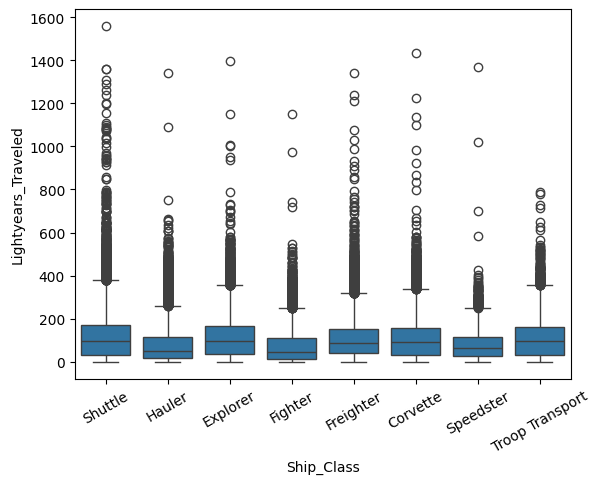

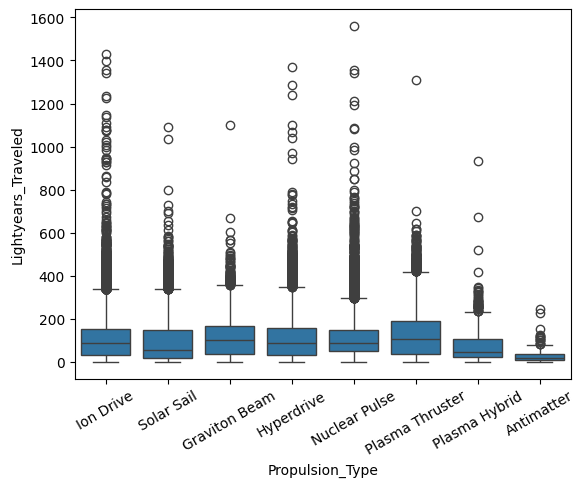

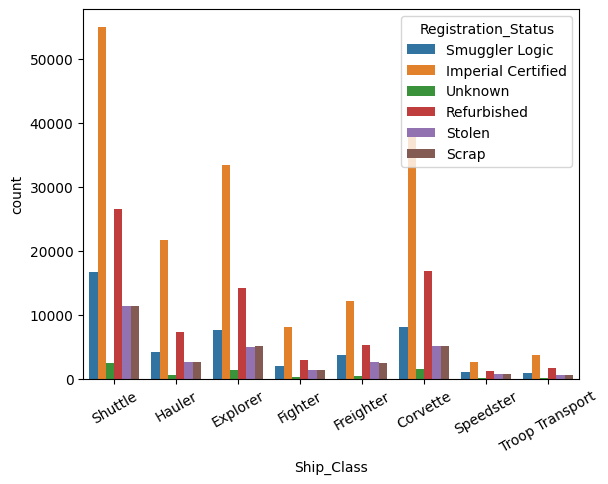

In [15]:
sns.boxplot(x='Ship_Class', y='Lightyears_Traveled', data=df_merged2)
plt.xticks(rotation=30)
plt.show()
sns.boxplot(x='Propulsion_Type', y='Lightyears_Traveled', data=df_merged2)
plt.xticks(rotation=30)
plt.show()
sns.countplot(data=df_merged2, x="Ship_Class", hue="Registration_Status")
plt.xticks(rotation=30)
plt.show()


**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

In [1]:
# CODE CELL: Data cleaning, preprocessing

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

In [2]:
# CODE CELL: Apply feature ecoding and define your features (X)

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [3]:
# CODE CELL: Train-Test split & train the Linear Regression model

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [4]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [7]:
# CODE CELL: Train-Test split & train the Decision Tree model.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [6]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*
* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |